In [5]:
# import matplotlib

# # ==========================================
# # 1. SETUP PLOTTING DISCIPLINE
# # ==========================================
# BASE_FONT_SIZE = 20
# INSET_FONT_SIZE = 12

# custom_rcparams = {
#     "font.family": "serif",
#     "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
#     "font.size": BASE_FONT_SIZE,
#     "axes.labelsize": BASE_FONT_SIZE,
#     "axes.titlesize": BASE_FONT_SIZE,
#     "legend.fontsize": 15,
#     "xtick.labelsize": 25,
#     "ytick.labelsize": 25,
#     "xtick.color": "white",
#     "ytick.color": "white",
#     "xtick.labelcolor": "black",
#     "ytick.labelcolor": "black",
#     "xtick.major.pad": 8,
#     "ytick.major.pad": 2,
#     "axes.linewidth": 1.0,
#     "lines.linewidth": 1,
#     "lines.markersize": 5,
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.top": True,
#     "xtick.bottom": True,
#     "ytick.left": True,
#     "ytick.right": True,
#     "xtick.major.size": 8,
#     "xtick.major.width": 1.5,
#     "ytick.major.size": 8,
#     "ytick.major.width": 1.5,
#     "xtick.minor.size": 3,
#     "ytick.minor.size": 3,
#     "figure.dpi": 600,
#     "savefig.dpi": 300,
#     "text.usetex": False,
# }
# matplotlib.rcParams.update(custom_rcparams)

Step 1: Executing Rotation Curve Interpolation
Calculated Spline Values and Gradients at Ring Centers:
  Ring 1 (14.9 kpc) -> Observed: 297.2 km/s | Spline: 297.2 km/s | dv/dR: -1.28 km/s/kpc
  Ring 2 (18.2 kpc) -> Observed: 296.0 km/s | Spline: 296.0 km/s | dv/dR: 1.42 km/s/kpc
  Ring 3 (21.5 kpc) -> Observed: 304.5 km/s | Spline: 304.5 km/s | dv/dR: 2.20 km/s/kpc
  Ring 4 (24.8 kpc) -> Observed: 307.5 km/s | Spline: 307.5 km/s | dv/dR: 0.29 km/s/kpc


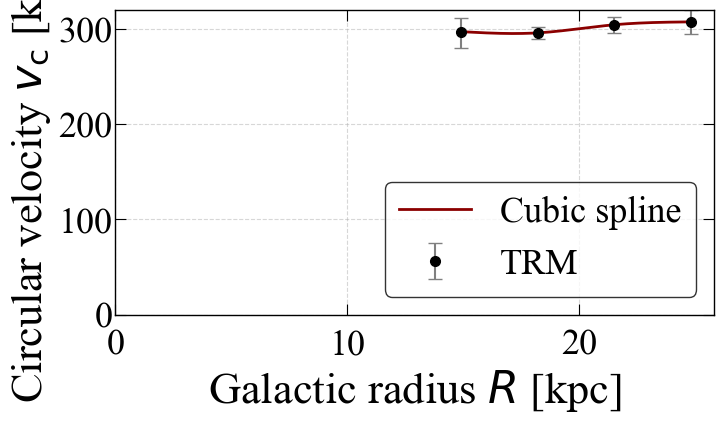

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# =====================================================================
# 1. CORE INTERPOLATION FUNCTIONS
# =====================================================================

def generate_kinematic_spline(radii, v_c):
    """
    Creates a natural cubic spline interpolation of the rotation curve.
    'natural' boundary conditions enforce zero second derivative at the edges,
    preventing artificial oscillation (Runge's phenomenon) at the boundaries.
    """
    
    sort_idx = np.argsort(radii)
    r_sorted = radii[sort_idx]
    v_sorted = v_c[sort_idx]
    
    spline_fit = CubicSpline(r_sorted, v_sorted, bc_type='natural')
    spline_deriv = spline_fit.derivative()
    
    return spline_fit, spline_deriv


# =====================================================================
# 2. PLOTTING & DISPLAY FUNCTION
# =====================================================================

def plot_spline_curve(radii, v_c, v_err, spline_fit):
    """
    Generates a clean plot of the data points vs. the continuous spline.
    """
    
    R_grid = np.linspace(min(radii), max(radii), 200)
    v_model_grid = spline_fit(R_grid)
    
    plt.figure(figsize=(8, 5))
    
    # spline
    plt.plot(R_grid, v_model_grid, color='darkred', lw=2, label='Cubic spline')
    
    # Data points with asymmetric error bars
    if v_err is not None:
        plt.errorbar(radii, v_c, yerr=v_err, fmt='o', color='black', ecolor='gray', 
                     capsize=5, elinewidth=1.5, markersize=7, label='TRM')
    else:
        plt.plot(radii, v_c, 'o', color='black', markersize=7, label='TRM')
        
    plt.xlabel('Galactic radius $R$ [kpc]')
    plt.ylabel('Circular velocity $v_{\mathrm{c}}$ [km/s]')
    
    # Pad the limits 
    #plt.xlim(min(radii) - 1, max(radii) + 1)
    plt.xlim(0, max(radii) + 1)
    
    # Adjusted y-limits slightly to accommodate the larger 37 km/s error bar on Ring 1
    plt.ylim(0, 320)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right', frameon=True)
    plt.tight_layout()
    plt.show()


# =====================================================================
# 3. EXECUTION PIPELINE
# =====================================================================

if __name__ == "__main__":
    # Input Data 
    ring_radii = np.array([14.9, 18.2, 21.5, 24.8]) # kpc
    ring_v_c   = np.array([297.223, 295.973, 304.49, 307.541]) # km/s
    
    # Matplotlib requires these to be positive absolute distances from the point
    ring_v_err = np.array([
        [16.732, 6.523, 8.984, 12.856],  # Absolute lower errors
        [14.339, 6.564, 8.252, 12.856]   # Upper errors
    ])
    
    print("Step 1: Executing Rotation Curve Interpolation")
    
    # Generate the continuous spline and its analytical derivative
    v_spline, dv_spline = generate_kinematic_spline(ring_radii, ring_v_c)
    
    print("Calculated Spline Values and Gradients at Ring Centers:")
    
    # extract the derivatives.
    for i, R in enumerate(ring_radii):
        v_eval = v_spline(R)
        dv_dR_eval = dv_spline(R)
        print(f"  Ring {i+1} ({R} kpc) -> Observed: {ring_v_c[i]:.1f} km/s | Spline: {v_eval:.1f} km/s | dv/dR: {dv_dR_eval:.2f} km/s/kpc")

    # Generate Output Plot
    plot_spline_curve(ring_radii, ring_v_c, ring_v_err, v_spline)

--- Step 2: Calculating Epicyclic Frequencies & Timescales ---

Ring 1 (14.9 kpc):
  Omega: 19.95 km/s/kpc | kappa: 27.29 km/s/kpc
  Resonance Ratio (kappa/Omega): 1.368
  Orbital Period (T_phi)   = 308.0 Myr
  Epicyclic Period (T_kappa) = 225.1 Myr

Ring 2 (18.2 kpc):
  Omega: 16.26 km/s/kpc | kappa: 23.98 km/s/kpc
  Resonance Ratio (kappa/Omega): 1.475
  Orbital Period (T_phi)   = 377.8 Myr
  Epicyclic Period (T_kappa) = 256.2 Myr

Ring 3 (21.5 kpc):
  Omega: 14.16 km/s/kpc | kappa: 21.53 km/s/kpc
  Resonance Ratio (kappa/Omega): 1.520
  Orbital Period (T_phi)   = 433.8 Myr
  Epicyclic Period (T_kappa) = 285.4 Myr

Ring 4 (24.8 kpc):
  Omega: 12.40 km/s/kpc | kappa: 17.74 km/s/kpc
  Resonance Ratio (kappa/Omega): 1.430
  Orbital Period (T_phi)   = 495.4 Myr
  Epicyclic Period (T_kappa) = 346.4 Myr



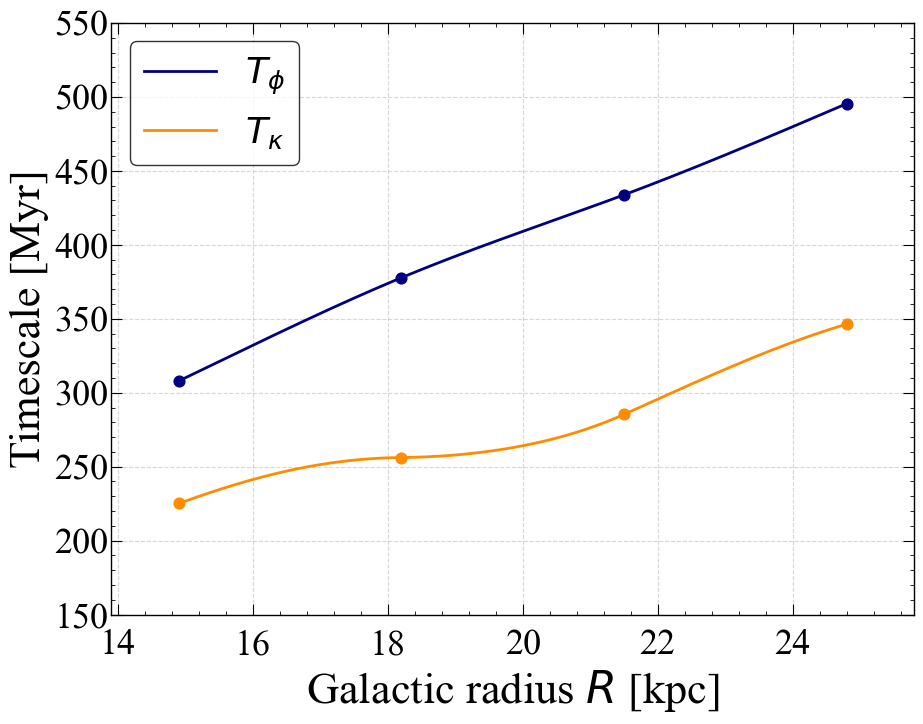

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator

# ==========================================
# 1. STYLE SETTINGS
# ==========================================
custom_rcparams = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    "font.size": 32,
    "axes.labelsize": 32,
    "axes.titlesize": 32,
    "legend.fontsize": 26,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "xtick.major.pad": 10,
    "ytick.major.pad": 2,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1,
    "lines.markersize": 5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "xtick.bottom": True,
    "ytick.left": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "figure.figsize": (10, 8), # Widened for two subplots
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
    "legend.loc": "best",
    "axes.edgecolor": "black",
    "xtick.labelcolor": "black",
    "ytick.labelcolor": "black",
    "text.usetex": False,
}

mpl.rcParams.update(custom_rcparams)

# =====================================================================
# 1. DEPENDENCY FROM STEP 1 (SPLINE GENERATOR)
# =====================================================================
def generate_kinematic_spline(radii, v_c):
    """Generates the natural cubic spline and its derivative."""
    sort_idx = np.argsort(radii)
    return CubicSpline(radii[sort_idx], v_c[sort_idx], bc_type='natural')

# =====================================================================
# 2. CORE FREQUENCY & TIMESCALE FUNCTIONS (MODULAR)
# =====================================================================

def calculate_frequencies(R, v_spline):
    """
    Calculates the angular frequency (Omega) and epicyclic frequency (kappa).
    R: Radius in kpc (can be a single float or a numpy array)
    v_spline: The fitted CubicSpline object from Step 1
    Returns: Omega, kappa in units of (km/s/kpc)
    """
    # 1. Generate the derivative object from the spline
    dv_spline = v_spline.derivative()
    
    # 2. Evaluate velocity and derivative directly from the spline
    v_c = v_spline(R)
    dv_dR = dv_spline(R)
    
    # 3. Core Physics Equations
    Omega = v_c / R
    
    # kappa^2 = 2*Omega^2 + 2*Omega*(dv/dR)
    kappa = np.sqrt(2 * Omega**2 + 2 * Omega * dv_dR)
    
    return Omega, kappa

def calculate_timescales(Omega, kappa):
    """
    Converts frequencies into physical timescales in Megayears (Myr).
    Uses the standard conversion: 1 km/s/kpc = 1/977.8 Myr^-1
    """
    CONVERSION_FACTOR = 977.8
    
    T_phi = (2 * np.pi / Omega) * CONVERSION_FACTOR
    T_kappa = (2 * np.pi / kappa) * CONVERSION_FACTOR
    
    return T_phi, T_kappa

# =====================================================================
# 3. PLOTTING & DISPLAY FUNCTION
# =====================================================================

def plot_galactic_clocks(R_grid, T_phi_grid, T_kappa_grid, ring_R, ring_T_phi, ring_T_kappa):
    """
    Generates a dual-axis plot showing timescales and the orbital resonance ratio.
    """
    fig, ax1 = plt.subplots()

    ax1.plot(R_grid, T_phi_grid, color='navy', lw=2, label='$T_\phi$')
    ax1.plot(R_grid, T_kappa_grid, color='darkorange', lw=2, label='$T_\kappa$')
    
    
    ax1.scatter(ring_R, ring_T_phi, color='navy', s=60, zorder=5)
    ax1.scatter(ring_R, ring_T_kappa, color='darkorange', s=60, zorder=5)
    
    ax1.set_xlabel('Galactic radius $R$ [kpc]')
    ax1.set_ylabel('Timescale [Myr]')
    
    
    ax1.set_xlim(min(ring_R) - 1, max(ring_R) + 1)
    ax1.set_ylim(150, 550)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left', frameon=True)

    # 4 minor ticks
    ax1.xaxis.set_minor_locator(AutoMinorLocator(5)) 
    ax1.yaxis.set_minor_locator(AutoMinorLocator(5))

    plt.savefig('time_periods.pdf', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

# =====================================================================
# 4. EXECUTION PIPELINE
# =====================================================================

if __name__ == "__main__":
    # 1. Input Data
    ring_radii = np.array([14.9, 18.2, 21.5, 24.8]) # kpc
    ring_v_c   = np.array([297.223, 295.973, 304.49, 307.541]) # km/s
    
    print("--- Step 2: Calculating Epicyclic Frequencies & Timescales ---\n")
    
    # 2. Generate the Spline Object (from Step 1 logic)
    v_spline = generate_kinematic_spline(ring_radii, ring_v_c)
    
    # 3. Calculate values specifically at the 4 observed rings
    Omega_rings, kappa_rings = calculate_frequencies(ring_radii, v_spline)
    T_phi_rings, T_kappa_rings = calculate_timescales(Omega_rings, kappa_rings)
    
    for i, R in enumerate(ring_radii):
        ratio = kappa_rings[i] / Omega_rings[i]
        print(f"Ring {i+1} ({R} kpc):")
        print(f"  Omega: {Omega_rings[i]:.2f} km/s/kpc | kappa: {kappa_rings[i]:.2f} km/s/kpc")
        print(f"  Resonance Ratio (kappa/Omega): {ratio:.3f}")
        print(f"  Orbital Period (T_phi)   = {T_phi_rings[i]:.1f} Myr")
        print(f"  Epicyclic Period (T_kappa) = {T_kappa_rings[i]:.1f} Myr\n")

    # 4. Generate smooth grids strictly within the data boundaries for plotting
    R_grid = np.linspace(min(ring_radii), max(ring_radii), 200)
    Omega_grid, kappa_grid = calculate_frequencies(R_grid, v_spline)
    T_phi_grid, T_kappa_grid = calculate_timescales(Omega_grid, kappa_grid)
    
    # 5. Execute Plot
    plot_galactic_clocks(R_grid, T_phi_grid, T_kappa_grid, ring_radii, T_phi_rings, T_kappa_rings)

In [8]:
# import numpy as np
# from scipy.optimize import curve_fit
# from scipy.interpolate import CubicSpline

# # =====================================================================
# # 1. DEPENDENCY FROM STEP 1 (SPLINE GENERATOR)
# # =====================================================================
# def generate_kinematic_spline(radii, v_c):
#     """Generates the natural cubic spline for the rotation curve."""
#     sort_idx = np.argsort(radii)
#     return CubicSpline(radii[sort_idx], v_c[sort_idx], bc_type='natural')

# # =====================================================================
# # 2. THE KINEMATIC RING MODEL (SPLINE WRAPPER)
# # =====================================================================
# def create_v_R_model(v_spline):
#     """
#     A factory function that injects the spline into the kinematic model.
#     Returns a function properly formatted for scipy's curve_fit.
#     """
#     # Pre-compute the derivative object so it doesn't recalculate every loop
#     dv_spline = v_spline.derivative()
    
#     def v_R_model(R, t_impact, V_0, alpha):
#         """
#         R: Radius (array or float)
#         t_impact: Time since collision (Myr)
#         V_0: Kick velocity at reference radius R=15 kpc (km/s)
#         alpha: Power-law index of the kick decay
#         """
#         # 1. Extract frequencies natively from the spline
#         v_c = v_spline(R)
#         dv_dR = dv_spline(R)
#         Omega = v_c / R
#         kappa = np.sqrt(2 * Omega**2 + 2 * Omega * dv_dR)
        
#         # 2. Convert kappa to Myr^-1 for phase calculation
#         kappa_myr = kappa / 977.8 
        
#         # 3. Calculate the decaying amplitude
#         v_kick = V_0 * (R / 15.0)**(-alpha)
        
#         # 4. Return the oscillating radial velocity
#         return v_kick * np.sin(kappa_myr * t_impact)
    
#     return v_R_model

# # =====================================================================
# # 3. EXECUTION PIPELINE
# # =====================================================================
# if __name__ == "__main__":
#     # Input Data
#     ring_radii = np.array([14.9, 18.2, 21.5, 24.8]) # kpc
#     ring_v_c   = np.array([297.223, 295.973, 304.49, 307.541]) # km/s
#     #ring_v_R   = np.array([23.0, 49.0, 53.0, 44.0])
#     ring_v_R   = np.array([9.73993963, -0.81866769, -1.4475939, 13.23452213])

#     print("--- Step 3: Collision Age Estimation (Empirical Spline Model) ---\n")

    
#     empirical_spline = generate_kinematic_spline(ring_radii, ring_v_c)
    
    
#     fitting_model = create_v_R_model(empirical_spline)

    
#     bounds = ([10, 10, 0], [120, 500, 5]) 
#     popt, pcov = curve_fit(fitting_model, ring_radii, ring_v_R, p0=[80, 100, 2], bounds=bounds)

#     t_fit, V0_fit, alpha_fit = popt

    
#     print(f"Time Since Impact (t_impact) : {t_fit:.1f} Megayears")
#     print(f"Initial Kick at 15 kpc (V_0) : {V0_fit:.1f} km/s")
#     print(f"Kick Decay Power (alpha)     : {alpha_fit:.2f}\n")

#     print("Observed vs Modeled Radial Velocities:")
#     for i, R in enumerate(ring_radii):
#         v_mod = fitting_model(R, t_fit, V0_fit, alpha_fit)
#         print(f"  Ring {i+1} ({R} kpc): Obs = {ring_v_R[i]} km/s -> Mod = {v_mod:.1f} km/s")

In [9]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline

# =====================================================================
# 1. DEPENDENCY FROM STEP 1 (SPLINE GENERATOR)
# =====================================================================
def generate_kinematic_spline(radii, v_c):
    """Generates the natural cubic spline for the rotation curve."""
    sort_idx = np.argsort(radii)
    return CubicSpline(radii[sort_idx], v_c[sort_idx], bc_type='natural')

# =====================================================================
# 2. THE KINEMATIC RING MODEL (SPLINE WRAPPER)
# =====================================================================
def create_v_R_model(v_spline):
    """
    A factory function that injects the spline into the kinematic model.
    Returns a function properly formatted for scipy's curve_fit.
    """
    dv_spline = v_spline.derivative()
    
    def v_R_model(R, t_impact, V_0, alpha):
        v_c = v_spline(R)
        dv_dR = dv_spline(R)
        Omega = v_c / R
        kappa = np.sqrt(2 * Omega**2 + 2 * Omega * dv_dR)
        
        # Convert kappa to Myr^-1 for phase calculation
        kappa_myr = kappa / 977.8 
        
        # Calculate the decaying amplitude
        v_kick = V_0 * (R / 15.0)**(-alpha)
        
        # Return the oscillating radial velocity
        return v_kick * np.sin(kappa_myr * t_impact)
    
    return v_R_model

# =====================================================================
# 3. EXECUTION PIPELINE & STATISTICAL OUTPUT
# =====================================================================
if __name__ == "__main__":
    # Input Data
    ring_radii = np.array([14.9, 18.2, 21.5, 24.8]) # kpc
    ring_v_c   = np.array([297.223, 295.973, 304.49, 307.541]) # km/s
    #ring_v_R   = np.array([23.0, 49.0, 53.0, 44.0])
    ring_v_R   = np.array([9.73993963, -0.81866769, -1.4475939, 13.23452213])

    print("--- Step 3: Collision Age Estimation & Statistics ---\n")

    # 1. Generate models
    empirical_spline = generate_kinematic_spline(ring_radii, ring_v_c)
    fitting_model = create_v_R_model(empirical_spline)

    # 2.1. Spline
    v_spline = generate_kinematic_spline(ring_radii, ring_v_c)
    
    # T_kappa
    Omega_void, kappa_void = calculate_frequencies(13.88, v_spline)
    _, T_kappa_void = calculate_timescales(Omega_void, kappa_void)
    print(f"T_kappa at 13.88 kpc: {T_kappa_void:.1f} Myr\n")

    # 2. Execute the fit
    bounds = ([10, 10, 0], [120, 500, 5]) 
    popt, pcov = curve_fit(fitting_model, ring_radii, ring_v_R, p0=[80, 100, 2], bounds=bounds)
    t_fit, V0_fit, alpha_fit = popt

    # 3. Calculate Statistics
    # Standard errors derived from the covariance matrix
    perr = np.sqrt(np.diag(pcov))
    t_err, V0_err, alpha_err = perr

    # Residuals and Chi-Square equivalent (Residual Sum of Squares)
    modeled_v_R = fitting_model(ring_radii, *popt)
    residuals = ring_v_R - modeled_v_R
    rss = np.sum(residuals**2)  # Unweighted Chi-Squared
    
    # Degrees of Freedom
    dof = len(ring_radii) - len(popt)
    
    # Reduced Chi-Squared (Unweighted)
    reduced_chi_sq = rss / dof if dof > 0 else np.nan

    # R-squared Goodness of Fit
    ss_tot = np.sum((ring_v_R - np.mean(ring_v_R))**2)
    r_squared = 1 - (rss / ss_tot)

    # 4. Output Parameter Results
    print("Optimized Parameters")
    print(f"Time Since Impact (t_impact) : {t_fit:.1f} ± {t_err:.1f} Myr")
    print(f"Initial Kick at 15 kpc (V_0) : {V0_fit:.1f} ± {V0_err:.1f} km/s")
    print(f"Kick Decay Power (alpha)     : {alpha_fit:.2f} ± {alpha_err:.2f}\n")

    # 5. Output Model Statistics
    print("Fit Statistics")
    print(f"Degrees of Freedom (DOF)     : {dof}")
    print(f"Unweighted Chi-Squared (RSS) : {rss:.2f}")
    print(f"Reduced Chi-Squared          : {reduced_chi_sq:.2f}")
    print(f"R-squared (R^2)              : {r_squared:.4f}\n")

    # 6. Output Point-by-Point Comparison
    print("Observed vs Modeled Radial Velocities")
    for i, R in enumerate(ring_radii):
        print(f"  Ring {i+1} ({R} kpc): Obs = {ring_v_R[i]} km/s -> Mod = {modeled_v_R[i]:.1f} km/s (Res: {residuals[i]:.1f})")

--- Step 3: Collision Age Estimation & Statistics ---

T_kappa at 13.88 kpc: 207.0 Myr

Optimized Parameters
Time Since Impact (t_impact) : 94.5 ± 338.2 Myr
Initial Kick at 15 kpc (V_0) : 10.0 ± 155.3 km/s
Kick Decay Power (alpha)     : 1.31 ± 31.51

Fit Statistics
Degrees of Freedom (DOF)     : 1
Unweighted Chi-Squared (RSS) : 179.47
Reduced Chi-Squared          : 179.47
R-squared (R^2)              : -0.0839

Observed vs Modeled Radial Velocities
  Ring 1 (14.9 kpc): Obs = 9.73993963 km/s -> Mod = 4.9 km/s (Res: 4.9)
  Ring 2 (18.2 kpc): Obs = -0.81866769 km/s -> Mod = 5.7 km/s (Res: -6.5)
  Ring 3 (21.5 kpc): Obs = -1.4475939 km/s -> Mod = 5.5 km/s (Res: -6.9)
  Ring 4 (24.8 kpc): Obs = 13.23452213 km/s -> Mod = 5.1 km/s (Res: 8.1)


Geometric De-projection (Void as a Kinematic Scar)-
Average Void Radius      : 13.88 kpc
Void Angular Size (Δθ)   : 105.75 degrees
Fraction of Full Orbit   : 0.294 (or 29.4%)

 Physical Timescale Parameters (Spline Model)-
Local Circular Velocity  : 298.44 km/s
Full Orbital Period (T_φ): 285.7 Megayears

 Final Timescale Result-
Interaction Timescale    : 83.9 Megayears


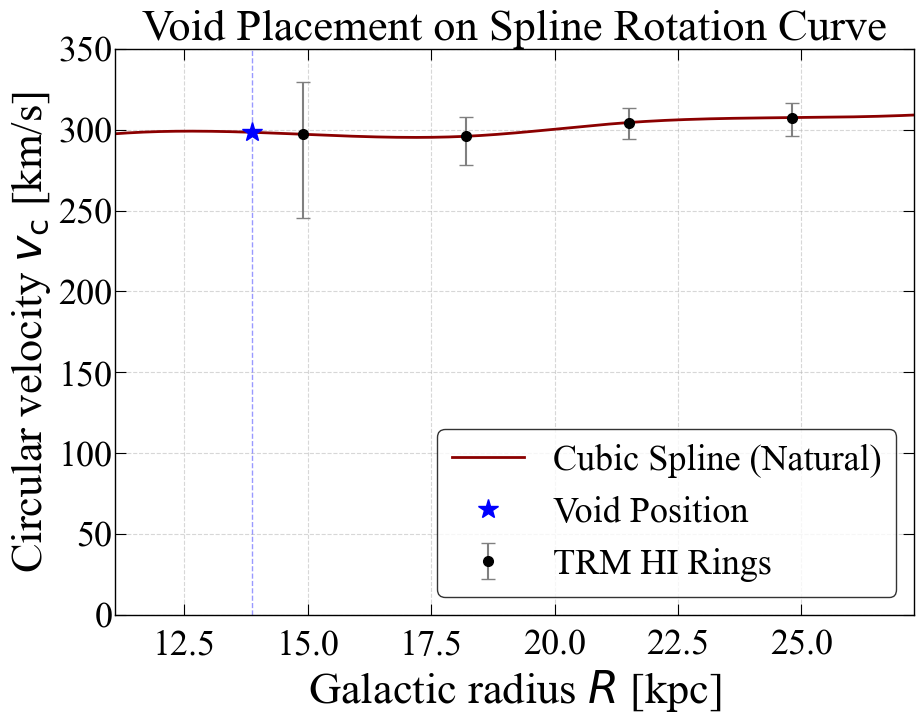

In [15]:
### Void Calculation:

#Calculation from the spline fit

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# ==========================================================
# 1. PARAMETERS & CONSTANTS
# ==========================================================
PA = np.radians(48.0)        # Position Angle (degrees)
incl = np.radians(51.76)     # Inclination (degrees)
scale = 0.329                # kpc per arcsecond
CONVERSION = 977.8           # (kpc / (km/s)) to Megayears

# Spline Data (from 4 observed HI rings)
ring_radii = np.array([14.9, 18.2, 21.5, 24.8]) # kpc
ring_v_c   = np.array([297.223, 295.973, 304.49, 307.541]) # km/s

# Asymmetric Error Bounds [Lower Errors, Upper Errors]
ring_v_err = np.array([
    [52.097, 17.518, 10.14, 11.329],  # Absolute lower errors
    [32.634, 11.846,  8.698, 8.922]   # Upper errors
])

def hms_to_deg(h, m, s):
    return (h + m/60.0 + s/3600.0) * 15.0

def dms_to_deg(d, m, s):
    sign = -1 if d < 0 else 1
    return sign * (abs(d) + m/60.0 + s/3600.0)

# ==========================================================
# 2. GEOMETRIC DE-PROJECTION OF THE VOID
# ==========================================================
# Center (AGN)
ra_c, dec_c = hms_to_deg(17, 29, 9.588425), dms_to_deg(-62, 26, 44.518200)
# Top Void Edge
ra_t, dec_t = hms_to_deg(17, 29, 12.171038), dms_to_deg(-62, 26, 27.349434)
# Bottom Void Edge
ra_b, dec_b = hms_to_deg(17, 29, 11.630122), dms_to_deg(-62, 27, 20.094748)

# Convert to physical angular offsets in arcseconds
cos_dec = np.cos(np.radians(dec_c))
dx_t = (ra_t - ra_c) * cos_dec * 3600
dy_t = (dec_t - dec_c) * 3600
dx_b = (ra_b - ra_c) * cos_dec * 3600
dy_b = (dec_b - dec_c) * 3600

def deproject_to_face_on(dx, dy, PA, incl):
    """ Rotates to align axes and stretches minor axis by 1/cos(i) """
    x_maj = dx * np.sin(PA) + dy * np.cos(PA)
    y_min = dx * np.cos(PA) - dy * np.sin(PA)
    
    x_deproj = x_maj
    y_deproj = y_min / np.cos(incl)
    
    R_arcsec = np.sqrt(x_deproj**2 + y_deproj**2)
    theta_rad = np.arctan2(y_deproj, x_deproj)
    return R_arcsec, theta_rad

r_top, th_top = deproject_to_face_on(dx_t, dy_t, PA, incl)
r_bot, th_bot = deproject_to_face_on(dx_b, dy_b, PA, incl)

# Calculate Void Arc Geometry
th_diff = np.abs(th_top - th_bot)
if th_diff > np.pi: th_diff = 2 * np.pi - th_diff
angle_deg = np.degrees(th_diff)

R_avg_kpc = ((r_top + r_bot) / 2.0) * scale

# ==========================================================
# 3. KINEMATIC TIMESCALE CALCULATION (VIA SPLINE)
# ==========================================================
# spline
sort_idx = np.argsort(ring_radii)
r_sorted = ring_radii[sort_idx]
v_sorted = ring_v_c[sort_idx]
spline_fit = CubicSpline(r_sorted, v_sorted, bc_type='natural')

# Evaluate the spline exactly at the void's deprojected radius
# Note: If R_avg_kpc falls outside [14.6, 24.4], the spline will extrapolate naturally.
v_c_void = float(spline_fit(R_avg_kpc))

# Calculate orbital frequency (Omega) and Period (T_phi) at the void
Omega = v_c_void / R_avg_kpc
T_phi = (2 * np.pi / Omega) * CONVERSION

# Interaction timescale = fraction of the orbit corresponding to the void's angular size
t_interaction = T_phi * (angle_deg / 360.0)

# ==========================================================
# 4. OUTPUT RESULTS
# ==========================================================
print("Geometric De-projection (Void as a Kinematic Scar)-")
print(f"Average Void Radius      : {R_avg_kpc:.2f} kpc")
print(f"Void Angular Size (Δθ)   : {angle_deg:.2f} degrees")
print(f"Fraction of Full Orbit   : {(angle_deg / 360.0):.3f} (or {angle_deg/360.0 * 100:.1f}%)")

print("\n Physical Timescale Parameters (Spline Model)-")
print(f"Local Circular Velocity  : {v_c_void:.2f} km/s")
print(f"Full Orbital Period (T_φ): {T_phi:.1f} Megayears")

print("\n Final Timescale Result-")
print(f"Interaction Timescale    : {t_interaction:.1f} Megayears")

# ==========================================================
# 5. VISUALIZATION
# ==========================================================
def plot_void_context(radii, v_c, v_err, spline_fit, void_r, void_v):
    
    min_r = min(min(radii), void_r) * 0.8
    max_r = max(max(radii), void_r) * 1.1
    R_grid = np.linspace(min_r, max_r, 200)
    v_model_grid = spline_fit(R_grid)
    
    plt.figure(figsize=(10, 8))
    
    # Plot spline line
    plt.plot(R_grid, v_model_grid, color='darkred', lw=2, label='Cubic Spline (Natural)')
    
    
    plt.errorbar(radii, v_c, yerr=v_err, fmt='o', color='black', ecolor='gray', 
                 capsize=5, elinewidth=1.5, markersize=7, label='TRM HI Rings')
                 
    # Plot the Void Location
    plt.plot(void_r, void_v, '*', color='blue', markersize=15, label='Void Position')
    plt.axvline(void_r, color='blue', linestyle='--', alpha=0.4)
        
    plt.xlabel('Galactic radius $R$ [kpc]')
    plt.ylabel('Circular velocity $v_{\mathrm{c}}$ [km/s]')
    plt.title('Void Placement on Spline Rotation Curve')
    plt.xlim(min_r, max_r)
    plt.ylim(0, 350)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right', frameon=True)
    plt.tight_layout()
    plt.show()

# Generate Output Plot
plot_void_context(ring_radii, ring_v_c, ring_v_err, spline_fit, R_avg_kpc, v_c_void)